In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('data.csv')

df.head()

,session_id,region,age_group,traffic_source,experiment_group,premium_member,used_mobile_app,ad_clicked,email_opened,coupon_used,visit_count_30d,engagement_level,purchased,payment_method,order_value_usd,returned_order,support_contacted,churned,fraudulent_transaction,fraud_alert
0,S0001,North,18-24,Social Media,A,Yes,Yes,No,No,Yes,4,Medium,No,NaN,0.0,Not Applicable,No,No,No,No
1,S0002,West,45+,Organic,A,No,No,No,No,No,0,Low,No,NaN,0.0,Not Applicable,No,Yes,No,No
2,S0003,East,35-44,Organic,A,No,Yes,No,No,No,4,Medium,No,NaN,0.0,Not Applicable,No,No,No,No
3,S0004,East,35-44,Paid Search,A,Yes,Yes,No,No,No,5,Medium,No,NaN,0.0,Not Applicable,No,No,No,No
4,S0005,East,35-44,Organic,B,Yes,No,Yes,No,Yes,5,Medium,No,NaN,0.0,Not Applicable,No,No,No,No


# Random variables

### Discrete Random variable

X = number of visits in the last 30 days of the randomly selected session

In [5]:
X_visits = df['visit_count_30d']
X_visits.unique()

array([ 4,  0,  5,  3,  2,  1,  8,  6,  7, 10,  9, 13, 11, 14, 12])

 
- Is X discrete or continuous ?  X is discrete

### Continuous Random variable

Y=order value of a randomly selected purchasing session

In [6]:
purchased_df = df[df['purchased'] == 'Yes']

Y = purchased_df['order_value_usd']

- Y is Continuous random variable

# Probability Functions

### Probability Mass Function (PMF)-discreate

X = number of visists in 30 days

In [7]:
visit_frequency = (df['visit_count_30d'].value_counts().sort_index().reset_index())
visit_frequency.columns =['visit_x', 'frequency']
visit_frequency

,visit_x,frequency
0,0,59
1,1,149
2,2,202
3,3,223
4,4,176
5,5,126
6,6,100
7,7,61
8,8,53
9,9,25


In [8]:
visit_frequency['probability'] = visit_frequency['frequency']/len(df)
visit_frequency.sort_values(by='probability')

,visit_x,frequency,probability
14,14,1,0.000833
12,12,2,0.001667
13,13,2,0.001667
11,11,4,0.003333
10,10,17,0.014167
9,9,25,0.020833
8,8,53,0.044167
0,0,59,0.049167
7,7,61,0.050833
6,6,100,0.083333


### Probability Density Function PDF - continuous


Y=order value of a randomly selected purchasing session
- Question `P(50 ≤ Y ≤ 100)`

In [9]:
order_value = df.loc[
    df['purchased'] == 'Yes',
    'order_value_usd'
]
order_value.head()

5      44.53
13     51.40
15     85.70
16    317.88
18    130.49
Name: order_value_usd, dtype: float64

indetifying the interval and counting how many observations fall inside it

In [ ]:
order_50_100 = order_value[
    (order_value >= 50) &
    (order_value <= 100)
]
len(order_50_100) 

178

calculating empirical probability 

In [11]:
probability_50_100 = len(order_50_100) / len(order_value)
probability_50_100

0.3603238866396761

In [12]:
interval_width = 100 - 50
density = probability_50_100 / interval_width
density

0.007206477732793522

In [13]:
prob_50_100 = interval_width * density
prob_50_100

0.3603238866396761

So about 36% of purchasing sessions have an order value between $50 and $100.

One value case 
- quesion `P(Y = 100)`

In [14]:
exact_100 = order_value[order_value == 100]

len(exact_100) / len(order_value)

0.0

### Cumculative Distribution Function (CDF)

#### CDF for discrete random variables

X = number of visits in the last 30 days of the randomly selected session
- Question `P(X≤3)`

In [15]:
X_visits = df['visit_count_30d']
vistis_cdf_3 = (X_visits <= 3).sum() / len(X_visits)
vistis_cdf_3

np.float64(0.5275)

#### CDF for continuous random variable

Y=order value of a randomly selected purchasing session
- Question `P(Y ≤ 100)`

In [16]:
order_value_100_or_less = order_value[
    order_value <= 100
]

In [17]:
print(len(order_value))
print(len(order_value_100_or_less))

494
268


In [18]:
cdf_100 = len(order_value_100_or_less) / len(order_value)
cdf_100

0.5425101214574899

About 54.25% of purchasing sessions have an order value of $100 or less.

# Multiple Random Variables

defining more than one random variables 
- X = visits count in 30 days
- Y = whether coupon used

## Joint probability

Question - `P(X = 3, Y = Yes)`

In [19]:
joint_visit30_coupon_usage = df[
    (df['visit_count_30d'] == 3) &
    (df['coupon_used'] == 'Yes')
]
len(joint_visit30_coupon_usage)

52

In [20]:
joint_visit30_coupon_usage_prob = len(joint_visit30_coupon_usage) / len(df)
joint_visit30_coupon_usage_prob

0.043333333333333335

## Marginal Probability

Question - `P(X = 3)` 

In [21]:
marginal_visit30 = df[df['visit_count_30d'] == 3]
marginal_visit30_prob = len(marginal_visit30) / len(df)
marginal_visit30_prob

0.18583333333333332

Question - `P(Y = Yes)`

In [22]:
marginal_coupon_useage = df[df['coupon_used'] == 'Yes']
marginal_coupon_useage_prob = len(marginal_coupon_useage) / len(df)
marginal_coupon_useage_prob

0.2325

## Conditional probability

- X = 3 | customers visit in last 30 days
- Y = Yes | customers coupon usage 
- Question `P(Y | X)`

In [24]:
# Joint probability
customers_visit3_coupon_usage = df[
    (df['visit_count_30d'] == 3) &
    (df['coupon_used'] == 'Yes')
]
visit3_coupon_use_prob = len(customers_visit3_coupon_usage) / len(df)

# Marginal Probability X=3 (customers visit equal=3)
customers_visit3 = df[df['visit_count_30d'] == 3]
visits3_prob = len(customers_visit3) / len(df)

# Probability of customers coupon usage if they visit 3 times
coupon_usage_prob_visit3_customers = len(customers_visit3_coupon_usage) / len(customers_visit3)

coupon_usage_prob_visit3_customers

0.23318385650224216

## Independent Probability

X=visit_count_30d                                                                                                                                                     
Y=coupon_used     
                                                                                                                                                
question - `are these events independent`. there are two methods to measure it
- Method 1 `Joint probabilit X and Y` = `Maginal prob X` * `Marginal prob Y`
- Method 2 `Conditional prob P(Y | X)` = `Marginal prob P(Y)`

#### method-1 

In [29]:
# Joint probability
joint_visit30_coupon_usage = df[
    (df['visit_count_30d'] == 3) &
    (df['coupon_used'] == 'Yes')
]
joint_visit30_coupon_usage_prob = len(joint_visit30_coupon_usage) / len(df)

# Marginal prob X 
marginal_visit30 = df[df['visit_count_30d'] == 3]
marginal_visit30_prob = len(marginal_visit30) / len(df)

# Marginal prob Y
marginal_coupon_useage = df[df['coupon_used'] == 'Yes']
marginal_coupon_useage_prob = len(marginal_coupon_useage) / len(df)

multiplication_of_marginal_probs = marginal_visit30_prob * marginal_coupon_useage_prob

print(joint_visit30_coupon_usage_prob)
print(multiplication_of_marginal_probs)

print(f"difference {abs(multiplication_of_marginal_probs-joint_visit30_coupon_usage_prob)}")

0.043333333333333335
0.04320625
difference 0.00012708333333333321


these two events are independent

#### method 2

In [30]:
# Joint probability
customers_visit3_coupon_usage = df[
    (df['visit_count_30d'] == 3) &
    (df['coupon_used'] == 'Yes')
]
visit3_coupon_use_prob = len(customers_visit3_coupon_usage) / len(df)

# Marginal Probability X=3 (customers visit equal=3)
customers_visit3 = df[df['visit_count_30d'] == 3]
visits3_prob = len(customers_visit3) / len(df)

# Probability of customers coupon usage if they visit 3 times
coupon_usage_prob_visit3_customers = len(customers_visit3_coupon_usage) / len(customers_visit3)

# Marginal prob Y
marginal_coupon_useage = df[df['coupon_used'] == 'Yes']
marginal_coupon_useage_prob = len(marginal_coupon_useage) / len(df)

print(f"Conditional prob: {coupon_usage_prob_visit3_customers}")
print(f"Marginal probs of Y: {marginal_coupon_useage_prob}")



Conditional prob: 0.23318385650224216
Marginal probs of Y: 0.2325


# Transformation

In [31]:
X = df['visit_count_30d']

Y = 2 * X

transformation_df = pd.DataFrame({
    'X': X,
    'Y': Y
})

transformation_df.head(10)

,X,Y
0,4,8
1,0,0
2,4,8
3,5,10
4,5,10
5,4,8
6,3,6
7,2,4
8,5,10
9,1,2


In [1]:
import numpy as np


In [2]:
p_1_3 = np.exp(-0.125 * 3 ) - np.exp(-0.125 * 8)
p_1_3

np.float64(0.3194098376195299)

# Probability Functions Practice

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Probability Density Function

### Exponential Distribition 

In [2]:
waiting_time = np.array([
    0.4, 1.2, 2.1, 0.8, 5.6,
    3.4, 7.8, 1.7, 4.2, 9.5,
    2.8, 6.1, 0.3, 3.9, 11.2,
    1.5, 5.1, 8.3, 2.4, 4.7
])

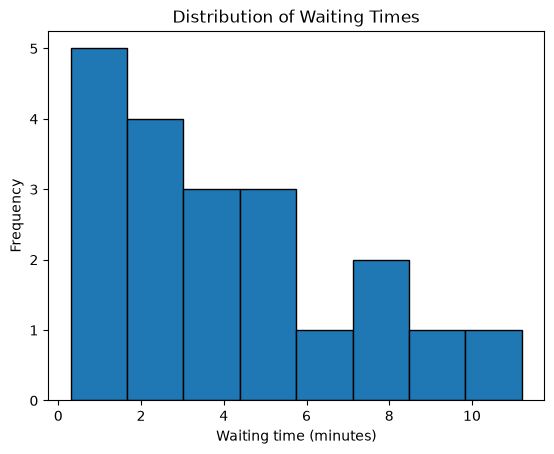

In [3]:
plt.hist(waiting_time, bins=8, edgecolor='black')

plt.xlabel("Waiting time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Waiting Times")

plt.show()

In [4]:
waiting_time_lambda = 1 / waiting_time.mean()
waiting_time_lambda

np.float64(0.24096385542168672)

average `0.24 ` events happen per minute

In [5]:
waiting_time_expected_value = 1 / waiting_time_lambda
waiting_time_expected_value

np.float64(4.15)

average `4.15` minutes we wait for the next event

we want to know `P(P(4 ≤ X ≤ 6)) = ?` what is the probability of waiting time will be a value between 4 and 6
- Formula ` P(a ≤ X ≤ b) = ∫ₐᵇ f_X(x) dx`
- Density `f_X(x) = λe^(-λx)`
- Full Formula `P(a ≤ X ≤ b) = ∫ₐᵇ  λe^(-λx) dx` 

In [6]:
p_wait_time_4_6 = (
    np.exp(- waiting_time_lambda * 4) - 
    np.exp(- waiting_time_lambda * 6)
)

p_wait_time_4_6

np.float64(0.14585798609131895)

### Noraml Distribution

In [7]:
height_cm = np.array([
    158, 162, 165, 167, 168,
    169, 170, 171, 172, 173,
    174, 175, 176, 177, 178,
    168, 170, 172, 174, 176,
    166, 169, 171, 173, 175,
    177, 179, 181, 164, 182
])

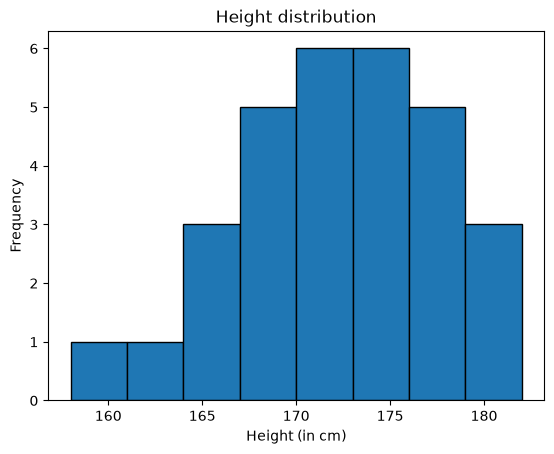

In [13]:
plt.hist(
    height_cm,
    bins=8,
    edgecolor='black'
)
plt.title("Height distribution")
plt.xlabel("Height (in cm)")
plt.ylabel("Frequency")
plt.show()

Probability Desnity Function
- Formula: `P(a ≤ X ≤ b) = ∫ₐᵇ f_X(x) dx`
- Density: `f_X(x) = 1 / (σ√(2π)) · e^(-((x - μ)² / (2σ²)))`
- I want : `P(170 ≤ X ≤  180) = ?`

#### Manual calculation

In [23]:
height_mean = height_cm.mean()
height_std = height_cm.std()

# Interval we want
x = np.linspace(170, 180, 1000)

# Normal PDF
density = (
    1 / (height_std * np.sqrt(2 * np.pi))
    *
    np.exp(
        -((x - height_mean) ** 2)
        /
        (2 * height_std ** 2)
    )
)

# Integral = probability
p_170_180 = np.trapezoid(density, x)

p_170_180

np.float64(0.5578893927754096)

#### Package calculation

In [25]:
from scipy.stats import norm

height_mean = height_cm.mean()
height_std = height_cm.std()

p_170_180 = (
    norm.cdf(180, loc=height_mean, scale=height_std)
    -
    norm.cdf(170, loc=height_mean, scale=height_std)
)

p_170_180

np.float64(0.5578894795620575)